In [1]:
import pandas as pd

In [2]:
import sys
sys.path.append('../../')

from tcremp.tcremp_cluster import run_dbscan_clustering, standardize_data, apply_pca

In [3]:
def get_sample_info(sample_name):
    data_path = f'/projects/immunestatus/pogorelyy/tcrempnet/{sample_name}'
    summary = pd.read_csv(f'{data_path}/yfv_{sample_name}_with_1_downsampled_summary_tcrempnet.tsv', sep='\t')
    enr_summary = summary[summary.enrichment_pvalue < 0.05]
    clonotype_info = pd.read_csv(f'{data_path}/yfv_{sample_name}_with_1_downsampled_tcremp_clusters.tsv', sep='\t')
    clonotype_info = clonotype_info[clonotype_info.cluster_id.isin(enr_summary.cluster_id)]
    embeddings = pd.read_csv(f'{data_path}/yfv_{sample_name}_with_1_downsampled_enriched_embeddings_tcremp.tsv', sep='\t')
    print(f'''
    sample: {sample_name}_with_1_downsampled
    clusters: {len(summary)}
    overall clonotypes: {summary.cluster_size.sum()}
    overall from background: {summary.background.sum()}
    overall from sample: {summary['sample'].sum()}
    
    clusters enriched: {len(enr_summary)}
    clusters enriched clonotypes: {enr_summary.cluster_size.sum()}
    clones enriched from background: {enr_summary.background.sum()}
    clones enriched from sample: {enr_summary['sample'].sum()}
    ''')
    return enr_summary, clonotype_info, embeddings

In [4]:
# singletons in background
# compare with tcrnet
# проверить на сгенеренном бэкграунде

In [5]:
samples = ['S1_F1', 'S2_F1', 'P1_F1', 'P2_F1', 'Q1_F1', 'Q2_F1']
sample_to_data = {}

for sample in samples:
    sample_to_data[sample] = get_sample_info(sample)


    sample: S1_F1_with_1_downsampled
    clusters: 11885
    overall clonotypes: 69927
    overall from background: 45467
    overall from sample: 24460
    
    clusters enriched: 500
    clusters enriched clonotypes: 10412
    clones enriched from background: 5063
    clones enriched from sample: 5349
    

    sample: S2_F1_with_1_downsampled
    clusters: 14582
    overall clonotypes: 85973
    overall from background: 40736
    overall from sample: 45237
    
    clusters enriched: 603
    clusters enriched clonotypes: 16582
    clones enriched from background: 5223
    clones enriched from sample: 11359
    

    sample: P1_F1_with_1_downsampled
    clusters: 15988
    overall clonotypes: 93827
    overall from background: 45939
    overall from sample: 47888
    
    clusters enriched: 439
    clusters enriched clonotypes: 8148
    clones enriched from background: 2491
    clones enriched from sample: 5657
    

    sample: P2_F1_with_1_downsampled
    clusters: 17322
    overa

In [6]:
data_for_plotting = {}
for sample in samples:
    embeddings = sample_to_data[sample][2]
    embeddings = embeddings[embeddings.source == 'sample'].drop(columns=['clone_id', 'cluster_id', 'source', 'enrichment_pvalue'])
    embeddings['sample'] = sample
    data_for_plotting[sample] = embeddings

In [7]:
all_info = pd.concat(data_for_plotting.values())

In [8]:
sample_labels = all_info['sample']

In [9]:
standardized = standardize_data(all_info.drop(columns=['sample']).values)
reduced = apply_pca(standardized, n_components=50)

In [10]:
all_info

,0_b_v,0_b_j,0_b_cdr3,1_b_v,1_b_j,1_b_cdr3,2_b_v,2_b_j,2_b_cdr3,3_b_v,...,2997_b_v,2997_b_j,2997_b_cdr3,2998_b_v,2998_b_j,2998_b_cdr3,2999_b_v,2999_b_j,2999_b_cdr3,sample
0,861.0,196.0,1360.0,891.0,107.0,1090.0,911.0,196.0,1140.0,911.0,...,878.0,107.0,870.0,877.0,0.0,1270.0,833.0,0.0,840.0,S1_F1
1,760.0,221.0,1430.0,712.0,0.0,980.0,668.0,221.0,1030.0,668.0,...,405.0,0.0,480.0,0.0,107.0,1300.0,716.0,107.0,650.0,S1_F1
2,760.0,221.0,1240.0,712.0,0.0,950.0,668.0,221.0,1060.0,668.0,...,405.0,0.0,550.0,0.0,107.0,1110.0,716.0,107.0,880.0,S1_F1
3,776.0,221.0,1360.0,814.0,0.0,710.0,838.0,221.0,880.0,838.0,...,809.0,0.0,630.0,820.0,107.0,1190.0,732.0,107.0,740.0,S1_F1
4,776.0,223.0,1390.0,814.0,198.0,940.0,838.0,223.0,1030.0,838.0,...,809.0,198.0,920.0,820.0,197.0,1360.0,732.0,197.0,710.0,S1_F1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4649,776.0,205.0,1500.0,814.0,184.0,730.0,838.0,205.0,1140.0,838.0,...,809.0,184.0,770.0,820.0,183.0,1150.0,732.0,183.0,600.0,Q2_F1
4650,776.0,205.0,1510.0,814.0,184.0,740.0,838.0,205.0,1150.0,838.0,...,809.0,184.0,780.0,820.0,183.0,1140.0,732.0,183.0,690.0,Q2_F1
4651,776.0,196.0,1480.0,814.0,107.0,730.0,838.0,196.0,1120.0,838.0,...,809.0,107.0,790.0,820.0,0.0,1110.0,732.0,0.0,660.0,Q2_F1
4652,776.0,212.0,1500.0,814.0,213.0,890.0,838.0,212.0,1140.0,838.0,...,809.0,213.0,950.0,820.0,202.0,1130.0,732.0,202.0,800.0,Q2_F1


In [11]:
reduced

array([[-74.97953413, -18.47992489,   5.10349543, ...,  -2.7102303 ,
         -0.81597872,  -2.44732325],
       [ 30.57545616, -51.78262261,   0.53972603, ...,  -3.57140767,
         -3.58339572,  -1.22119231],
       [ 31.90563414, -50.61157321,   0.40434628, ...,   0.72430331,
         -7.60474291,  -0.24146992],
       ...,
       [-43.73837884, -24.50425717,   4.55448838, ...,   1.06700437,
         -0.08223365,   0.79783754],
       [-34.86960577,  52.06460898,  27.26461215, ...,   1.54161157,
         -1.73620753,   1.70595048],
       [-73.28022418, -18.75872164,   0.88723094, ...,   1.31166506,
         -0.37235064,   0.68898619]])

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import seaborn as sns

def plot_embedding(embedding, labels, title):
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=labels, s=50, palette='tab10', alpha=0.8)
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend(loc='best', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    plt.tight_layout()
    plt.show()

def visualize_embeddings(reduced, samples):
    # PCA
    reduced_pca = PCA(n_components=2).fit_transform(reduced)
    plot_embedding(reduced_pca, samples, "PCA")

    # t-SNE
    reduced_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(reduced)
    plot_embedding(reduced_tsne, samples, "t-SNE")

    # UMAP
    reduced_umap = umap.UMAP().fit_transform(reduced)
    plot_embedding(reduced_umap, samples, "UMAP")


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


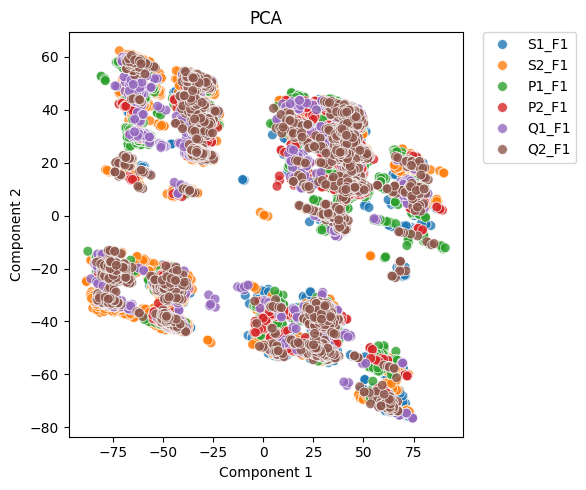

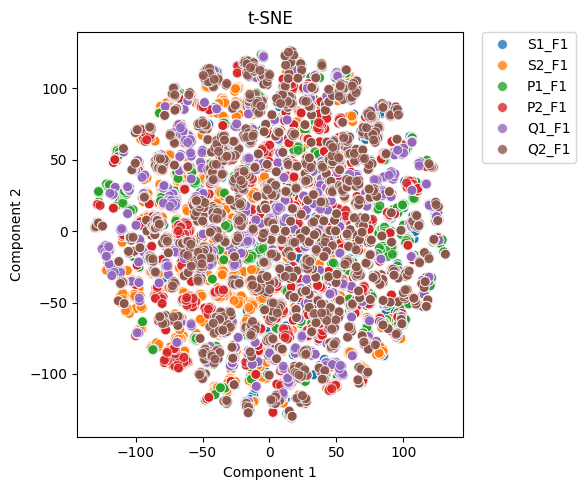

/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


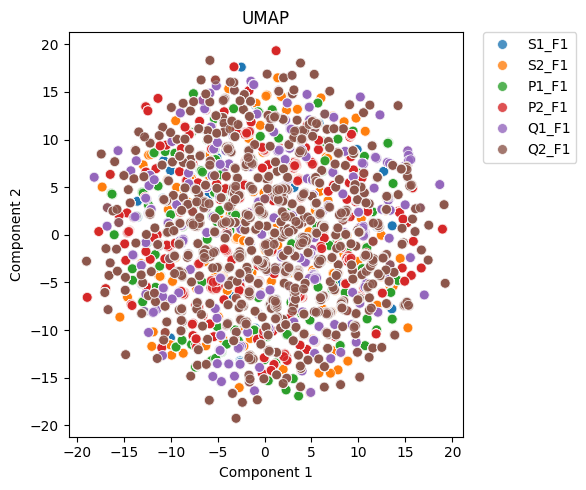

In [13]:
visualize_embeddings(reduced, sample_labels)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap

def plot_umap_grid(reduced, samples, neighbors_list=[5, 15, 30], min_dist_list=[0.01, 0.1, 0.5]):
    num_rows = len(neighbors_list)
    num_cols = len(min_dist_list)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 4 * num_rows))

    for i, n_neighbors in enumerate(neighbors_list):
        for j, min_dist in enumerate(min_dist_list):
            reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric='euclidean')
            embedding = reducer.fit_transform(reduced)

            ax = axes[i, j]
            sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=samples, s=30,
                            palette='tab10', alpha=0.8, ax=ax, legend=False)
            ax.set_title(f'n_neighbors={n_neighbors}, min_dist={min_dist}')
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may

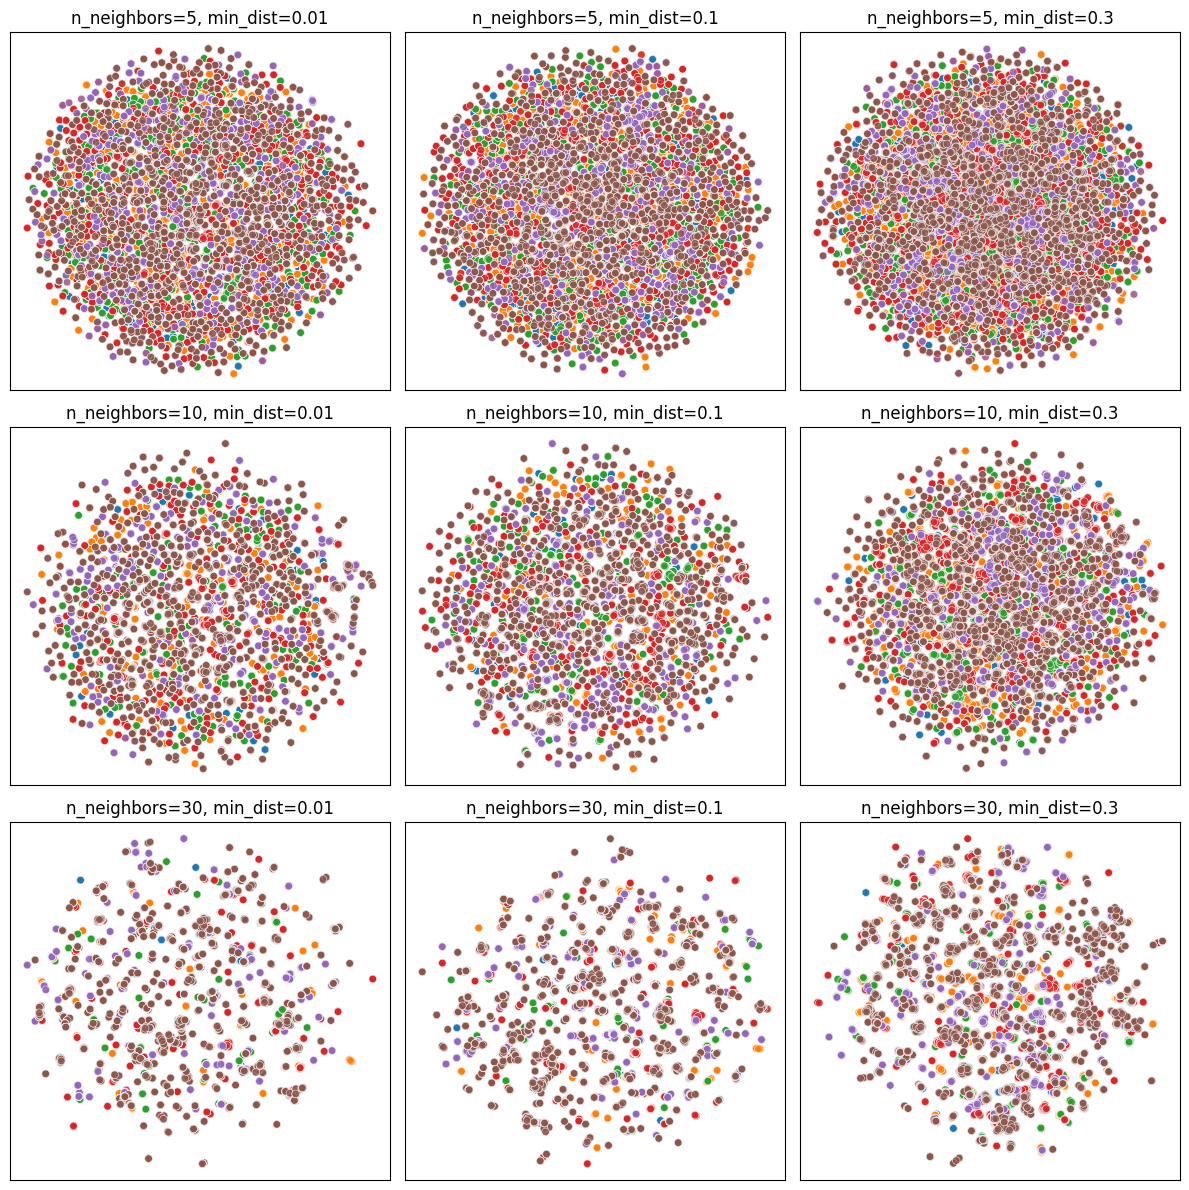

In [15]:
plot_umap_grid(reduced, sample_labels,
               neighbors_list=[5, 10, 30],
               min_dist_list=[0.01, 0.1, 0.3])


In [16]:
data_for_clust = all_info.drop(columns=['sample'])

In [17]:
import logging
logging.basicConfig(
        format="%(asctime)s - %(levelname)s - %(message)s", level=logging.INFO
    )

In [18]:
clustering = run_dbscan_clustering(data_for_clust, n_neighbors=8)

In [19]:
clustering = pd.DataFrame({'sample': sample_labels, 'cluster': clustering})

In [20]:
reduced.shape

(35766, 50)

In [21]:
from sklearn.cluster import HDBSCAN

In [22]:
res = HDBSCAN().fit_predict(reduced)

In [23]:
clustering = pd.DataFrame({'sample': sample_labels, 'cluster': res})

In [24]:
clustering.groupby('cluster').value_counts()

cluster  sample
-1       S2_F1     3165
         P2_F1     1514
         P1_F1     1513
         S1_F1     1513
         Q2_F1     1026
                   ... 
 2080    P2_F1        1
 2081    S2_F1        4
         P1_F1        2
         P2_F1        1
         S1_F1        1
Name: count, Length: 5110, dtype: int64

Метрика: euclidean, Метод: average


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


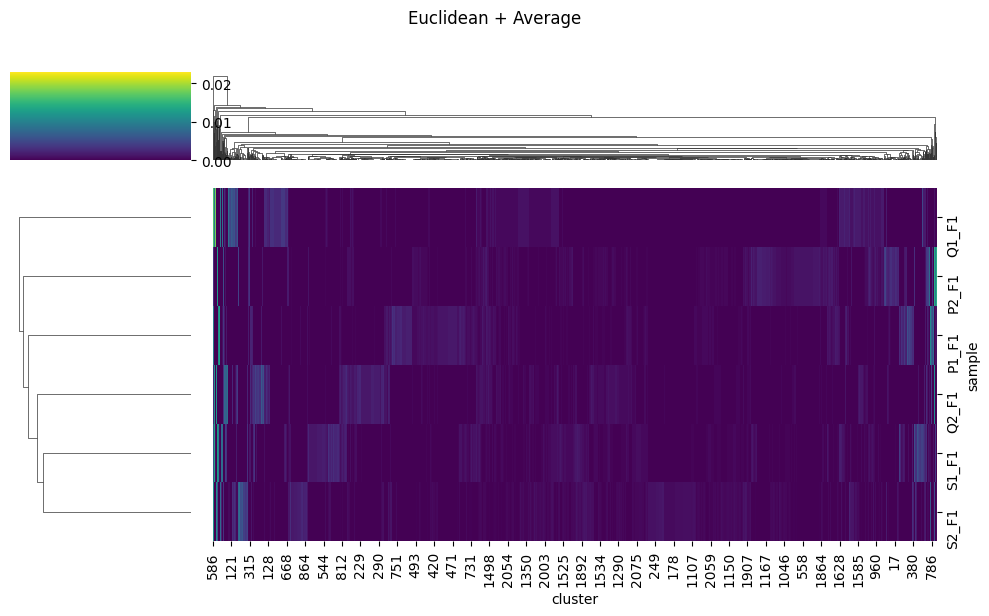

Метрика: euclidean, Метод: single


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


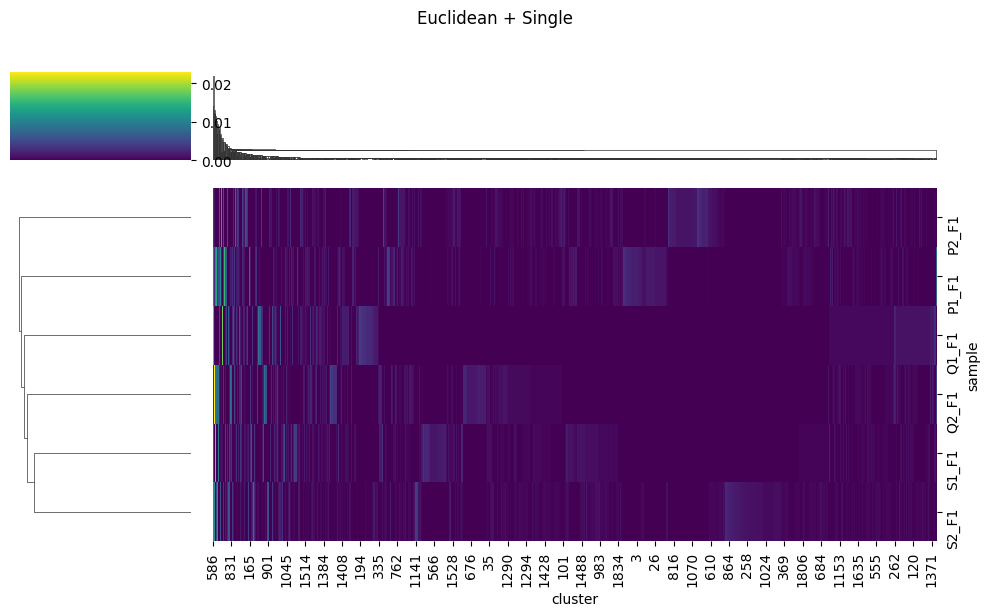

Метрика: euclidean, Метод: complete


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


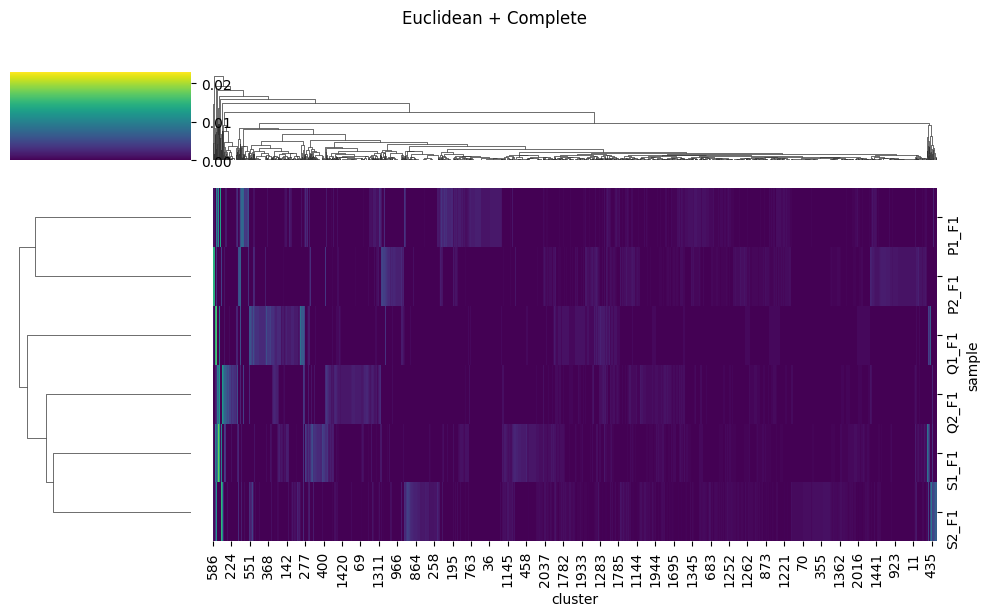

Метрика: euclidean, Метод: weighted


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


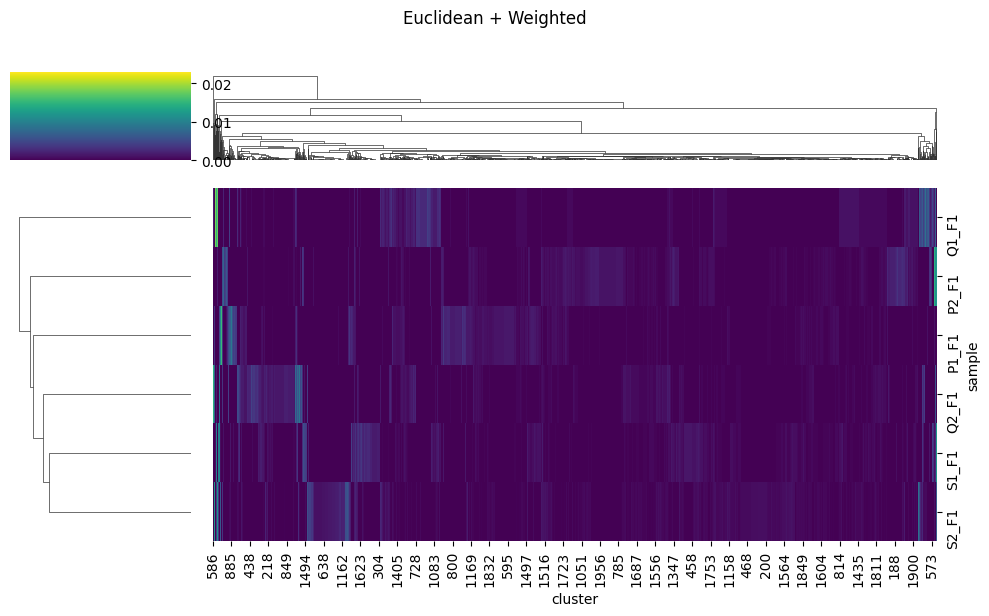

Метрика: euclidean, Метод: centroid


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


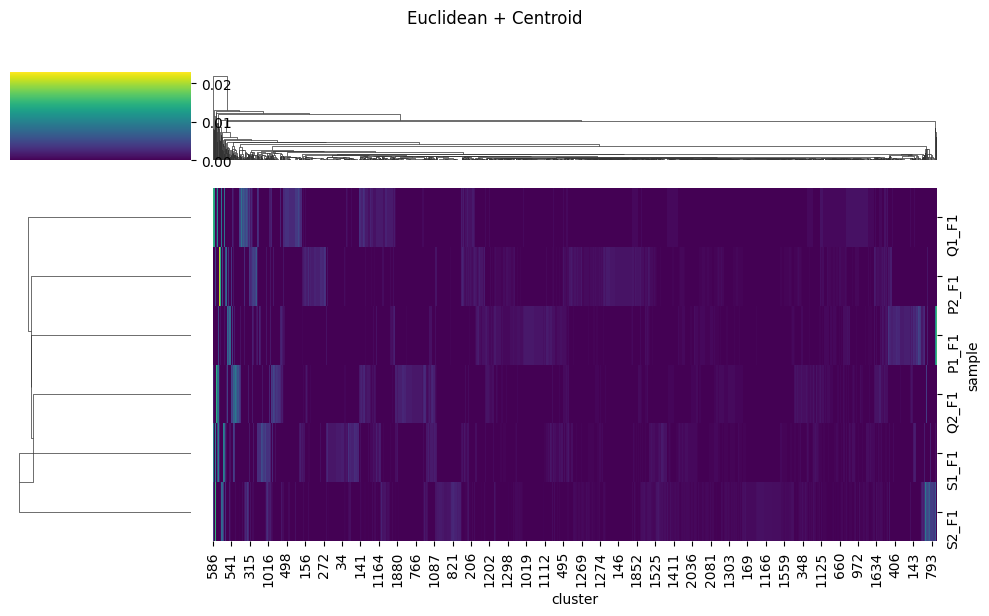

Метрика: cosine, Метод: average


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


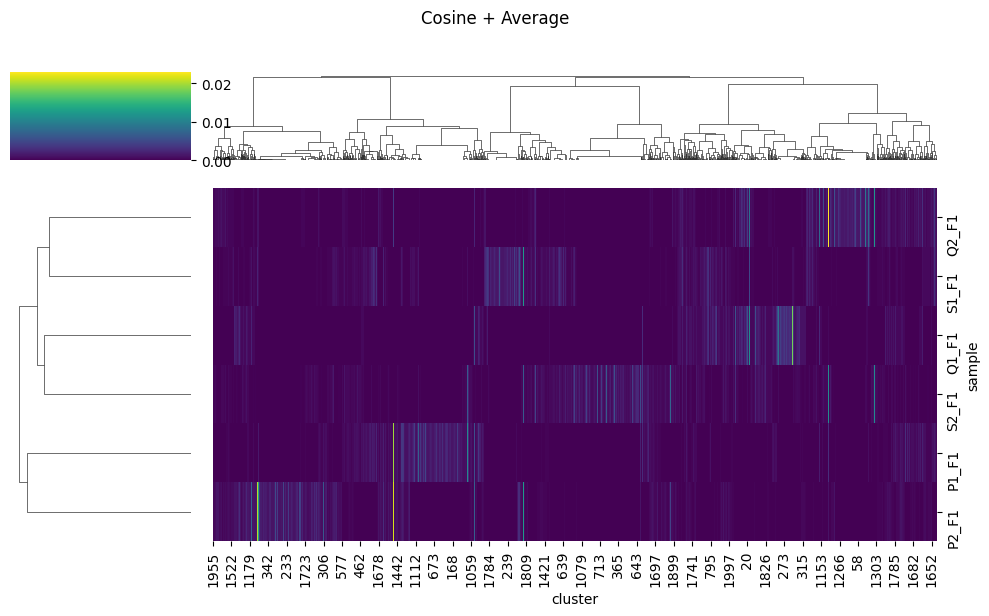

Метрика: cosine, Метод: single


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


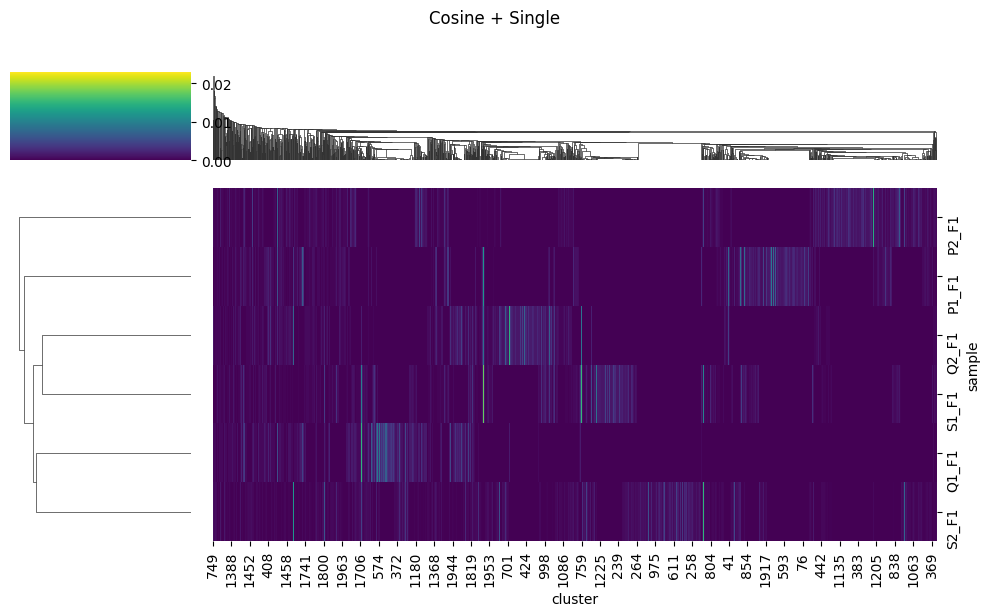

Метрика: cosine, Метод: complete


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


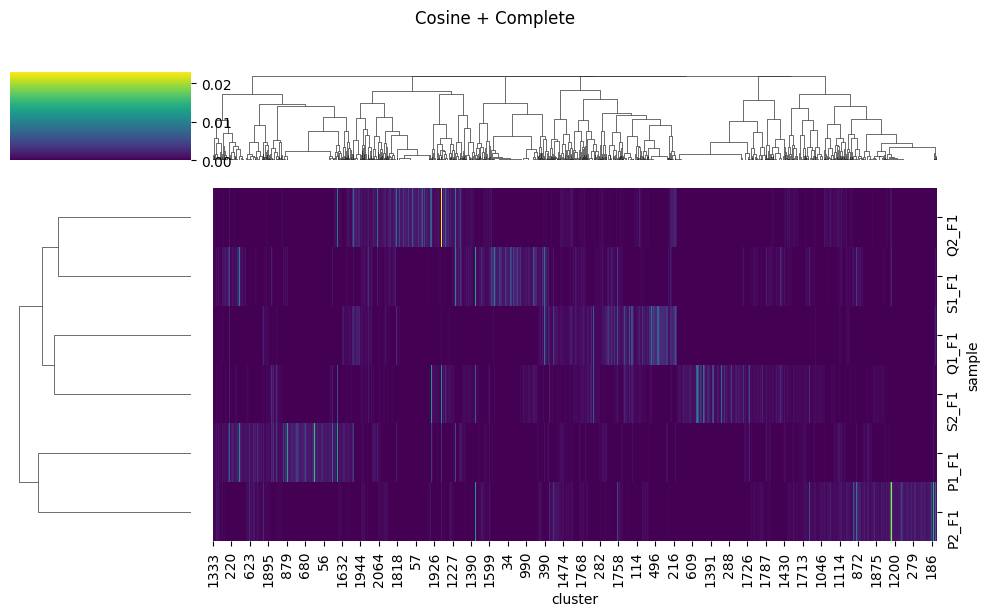

Метрика: cosine, Метод: weighted


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


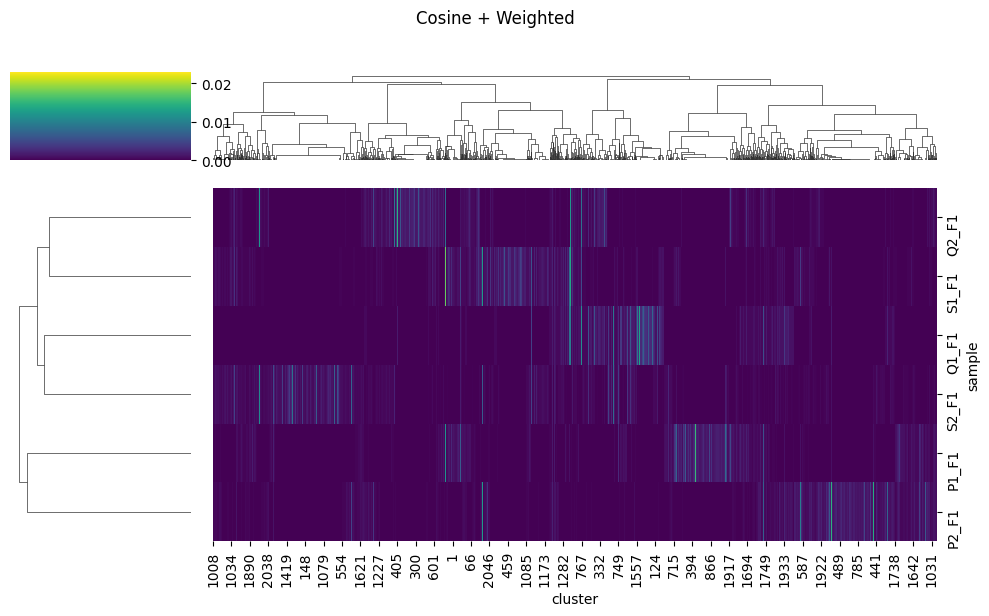

Метрика: cityblock, Метод: average


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


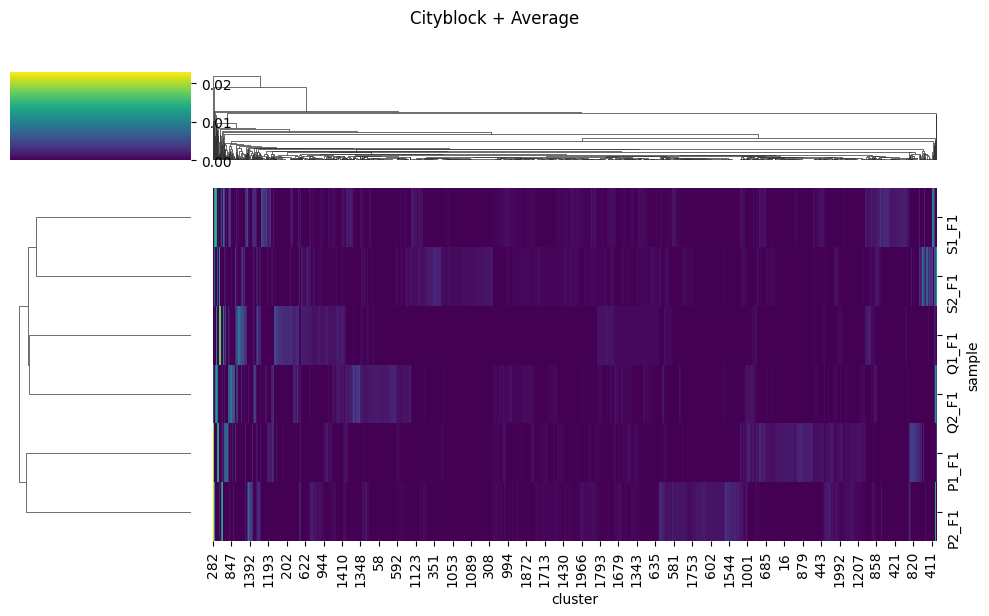

Метрика: cityblock, Метод: single


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


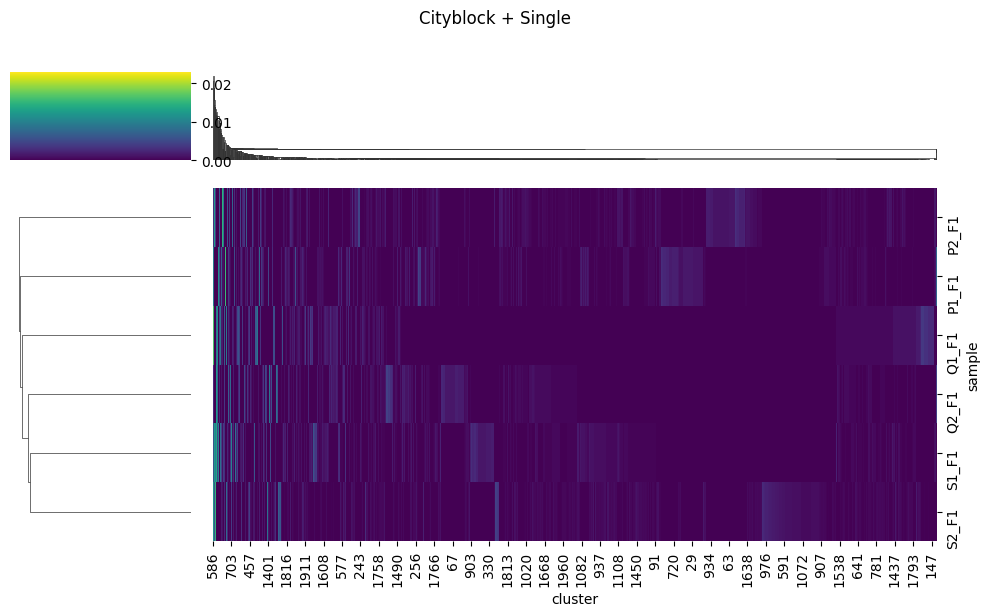

Метрика: cityblock, Метод: complete


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


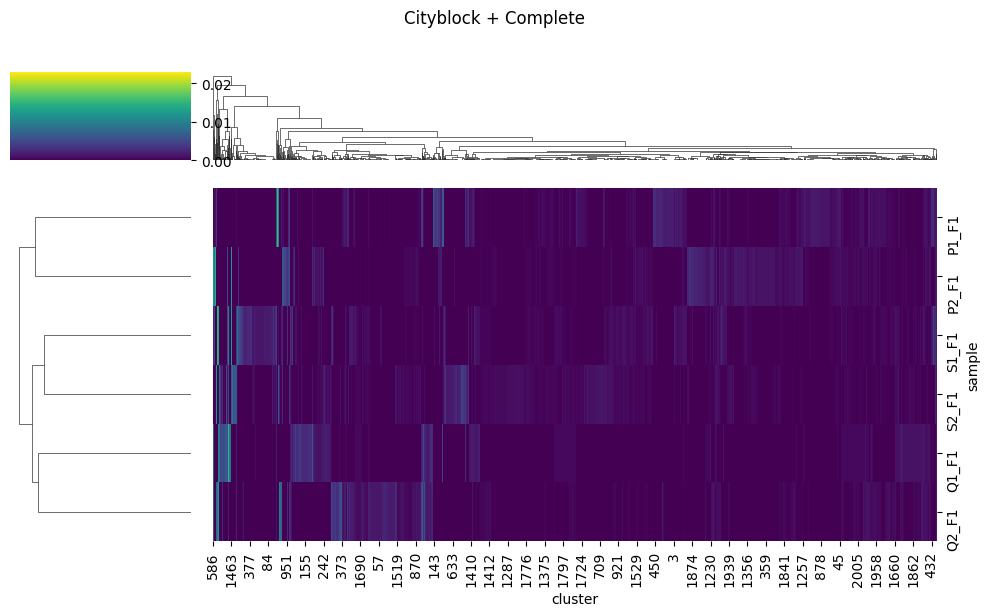

Метрика: cityblock, Метод: weighted


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


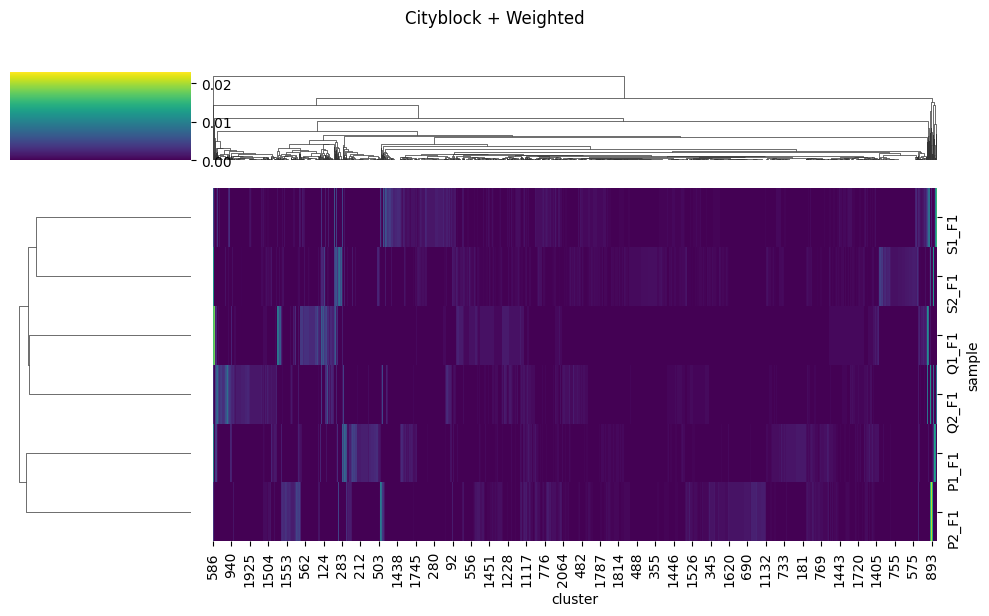

Метрика: correlation, Метод: average


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


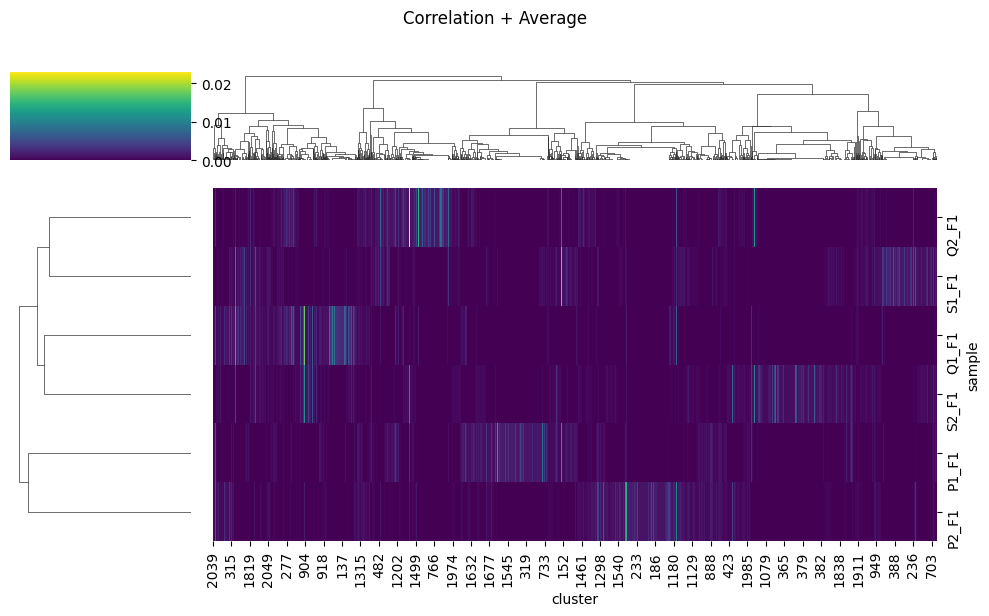

Метрика: correlation, Метод: single


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


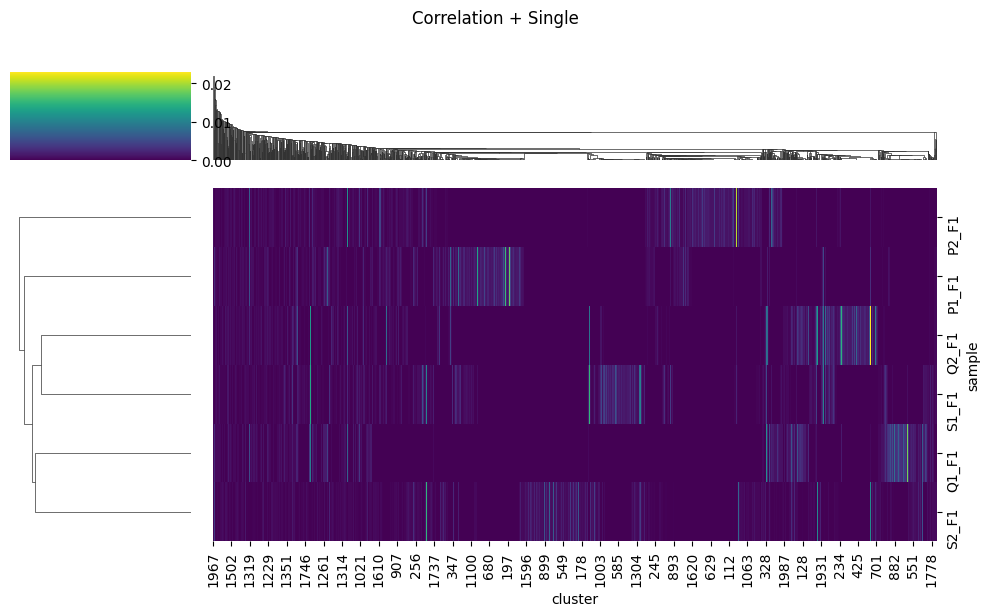

Метрика: correlation, Метод: complete


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


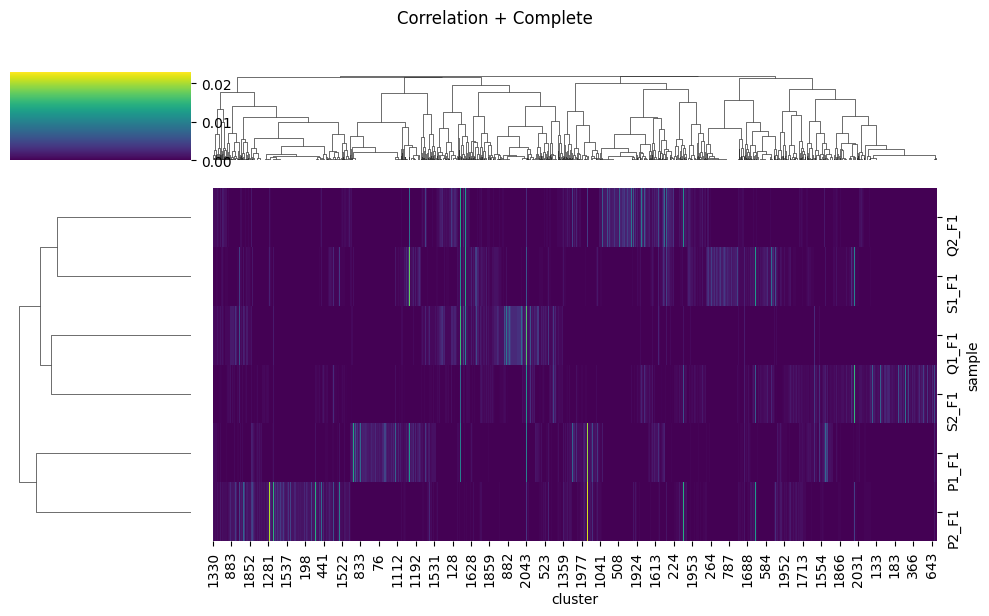

Метрика: correlation, Метод: weighted


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


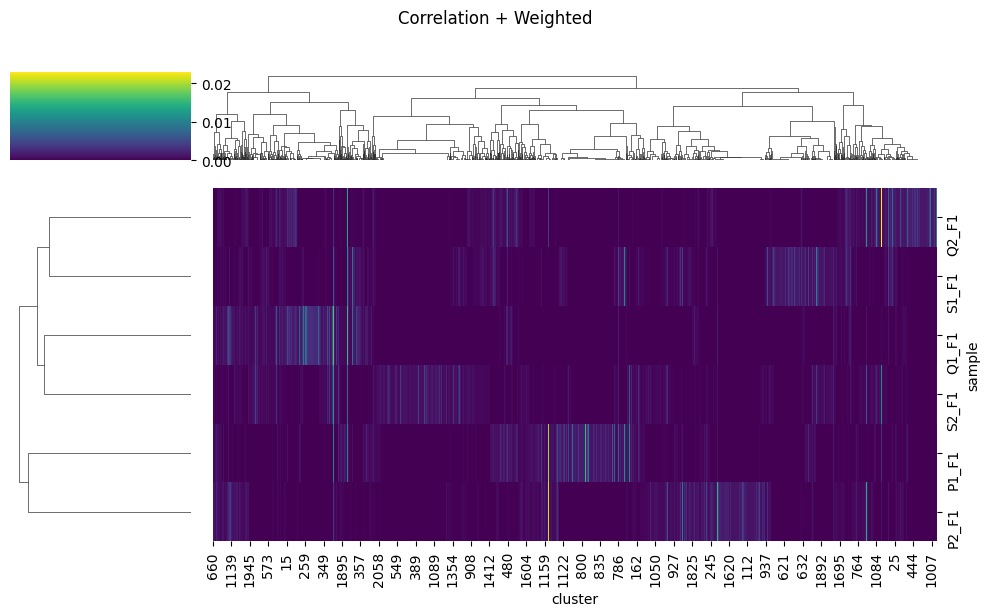

Метрика: chebyshev, Метод: average


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


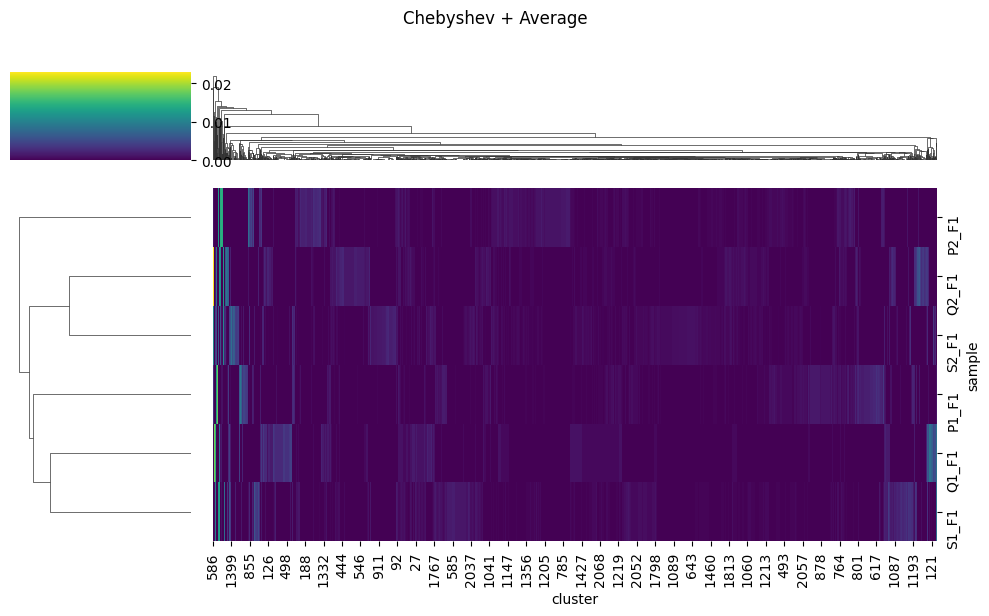

Метрика: chebyshev, Метод: single


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


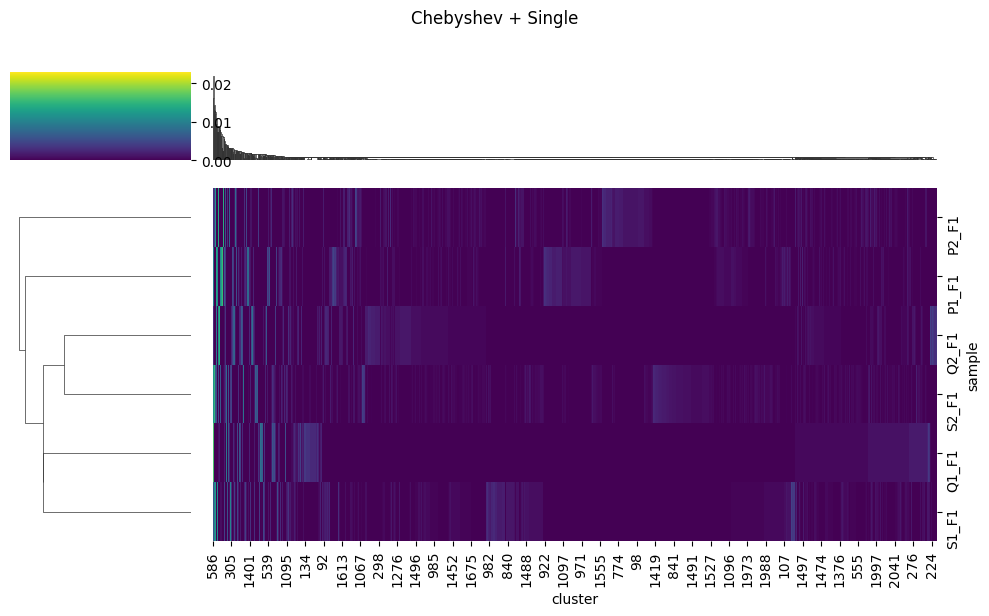

Метрика: chebyshev, Метод: complete


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


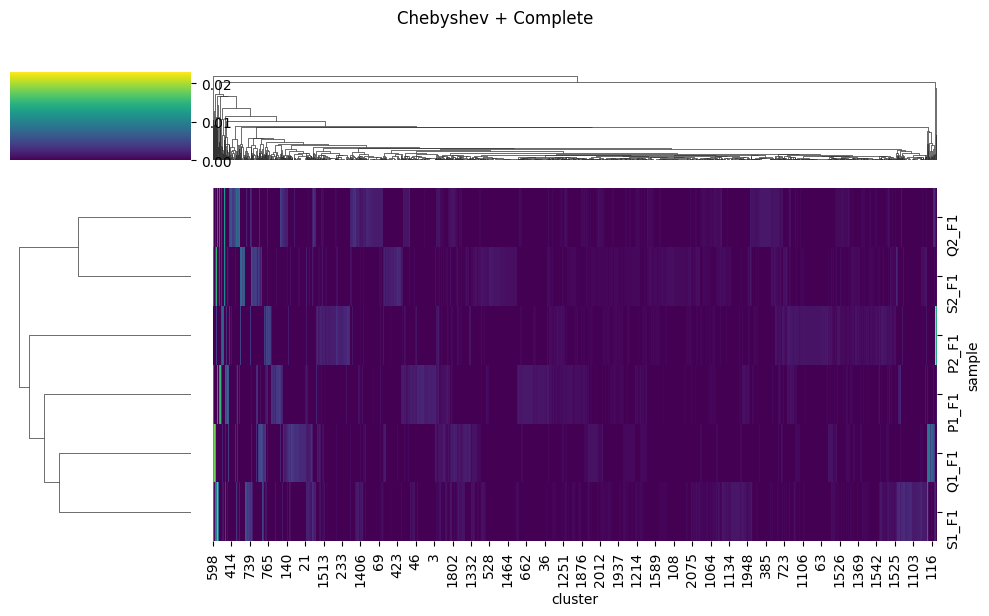

Метрика: chebyshev, Метод: weighted


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


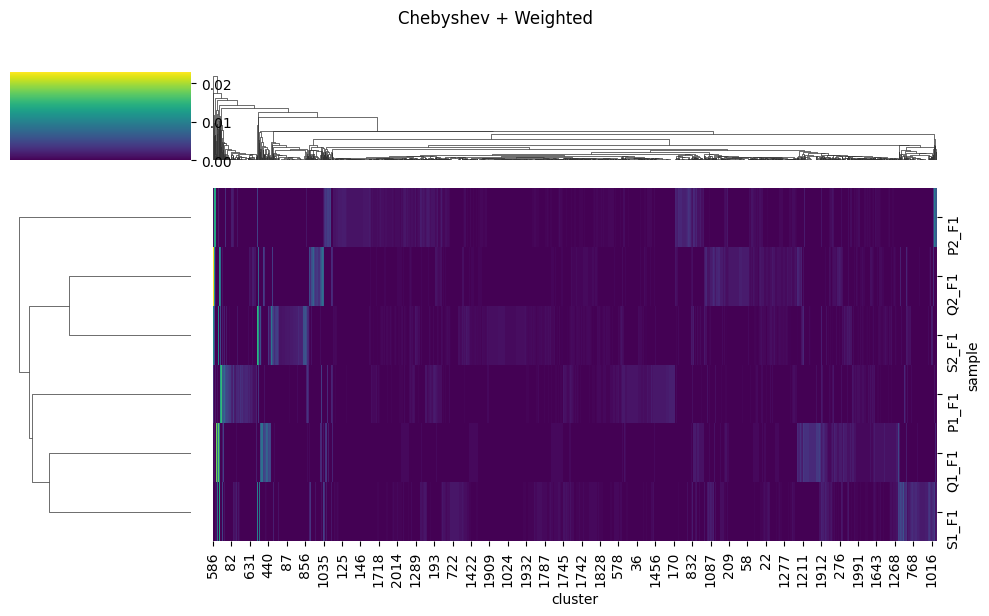

In [26]:
pivot_table = clustering.groupby(['sample', 'cluster']).size().unstack(fill_value=0).drop(columns=[-1])
pivot_table_normalized = pivot_table.div(pivot_table.sum(axis=1), axis=0)

metrics = ['euclidean', 'cosine', 'cityblock', 'correlation', 'chebyshev']
methods = ['average', 'ward', 'single', 'complete', 'weighted', 'centroid']

for metric in metrics:
    for method in methods:
        # Ward требует евклидову метрику
        if method == 'ward' or method == 'centroid' and metric != 'euclidean':
            continue
        
        print(f"Метрика: {metric}, Метод: {method}")
        g = sns.clustermap(
            pivot_table_normalized,
            metric=metric,
            method=method,
            cmap='viridis',
            figsize=(10, 6),
            # linewidths=0.1
        )
        g.fig.suptitle(f'{metric.capitalize()} + {method.capitalize()}', y=1.02)
        plt.tight_layout()
        plt.show()

In [27]:
pivot_table_bool = pivot_table_normalized.map(lambda x: 0 if x == 0 else 1)

Метрика: euclidean, Метод: average


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


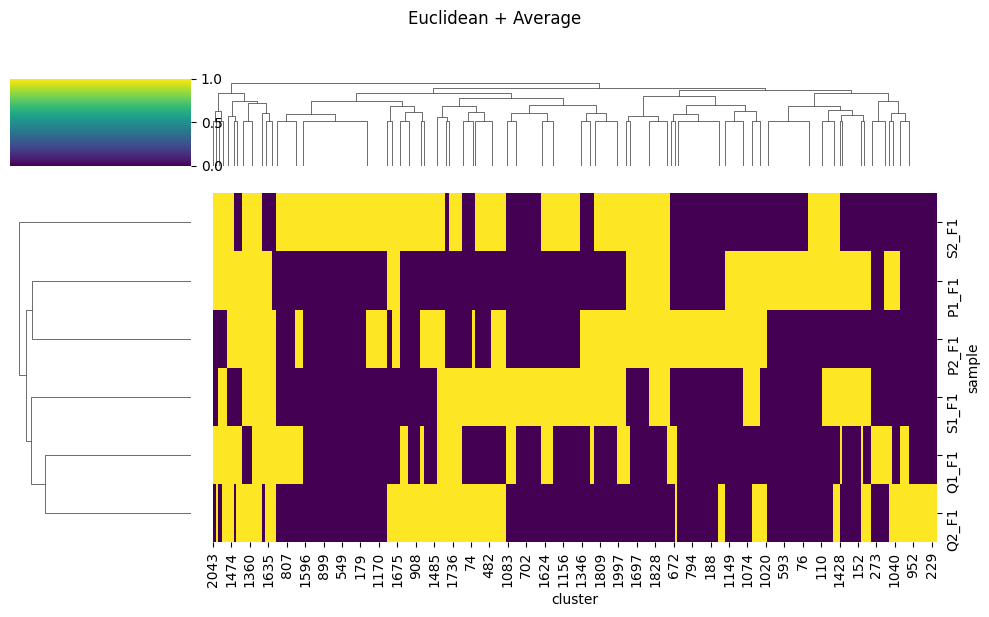

Метрика: euclidean, Метод: single


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


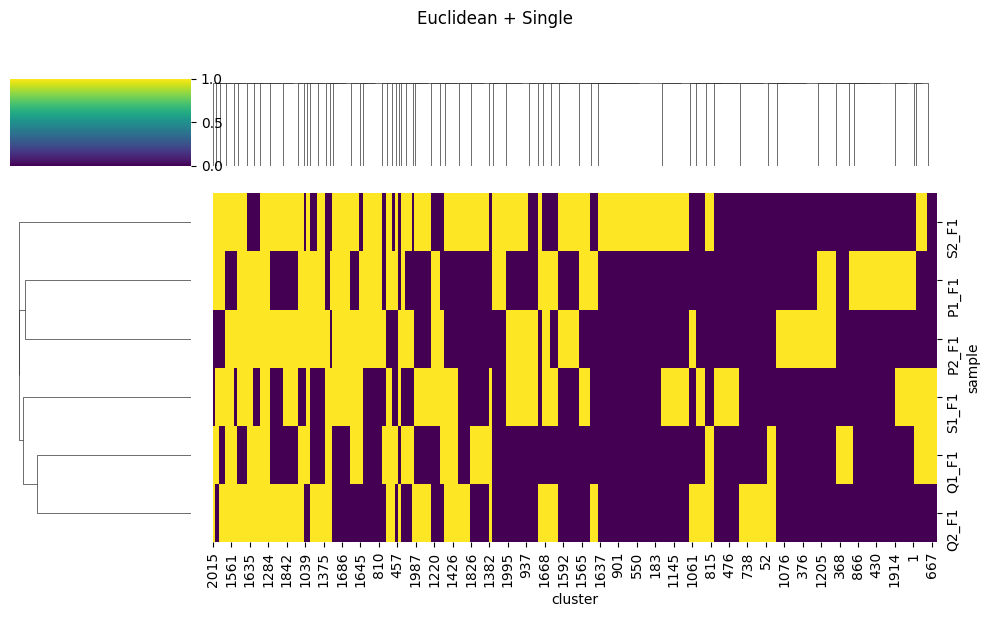

Метрика: euclidean, Метод: complete


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


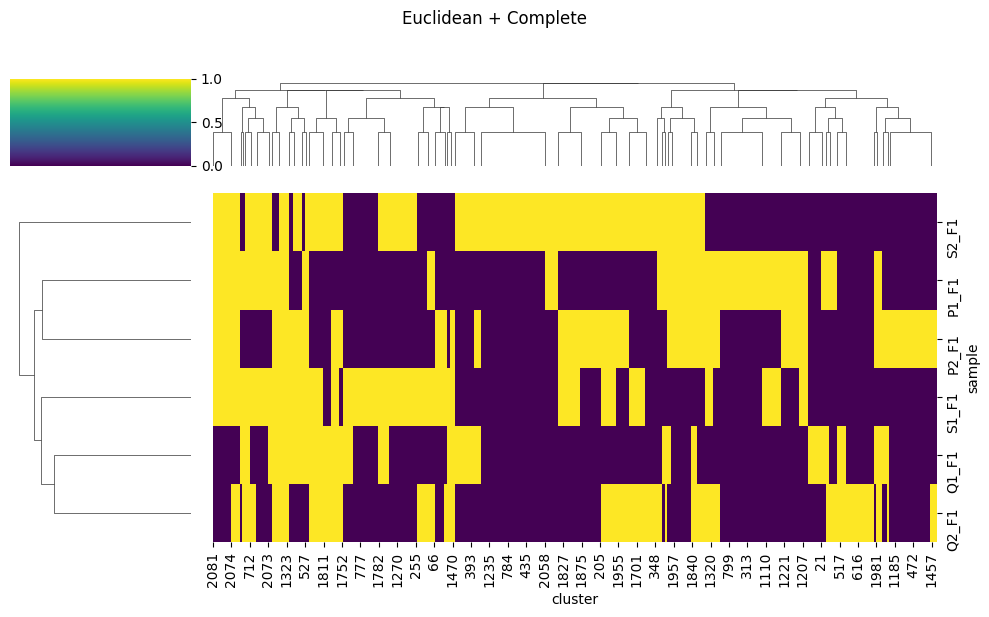

Метрика: euclidean, Метод: weighted


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


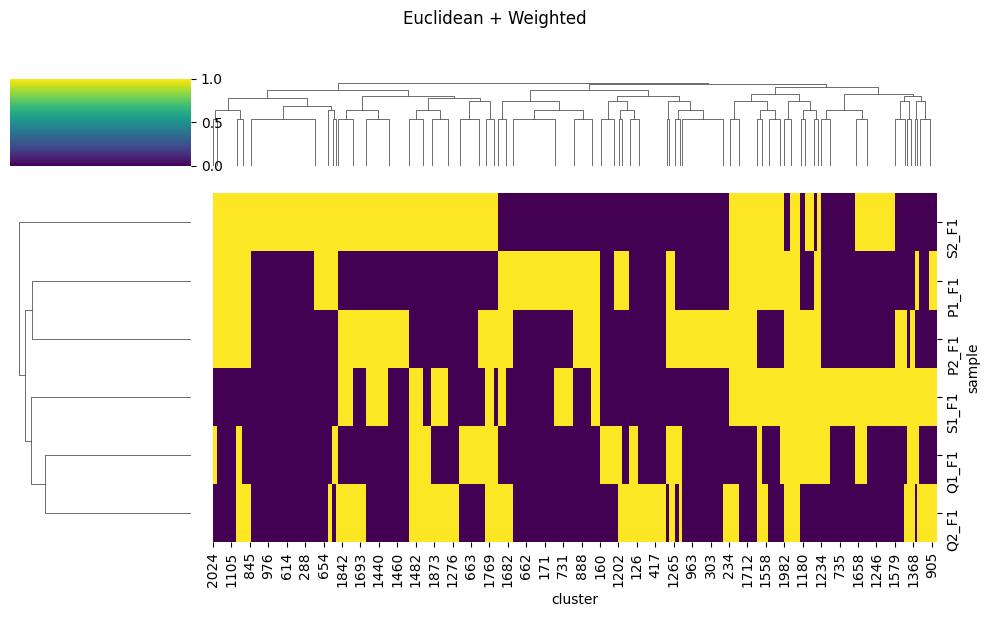

Метрика: euclidean, Метод: centroid


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


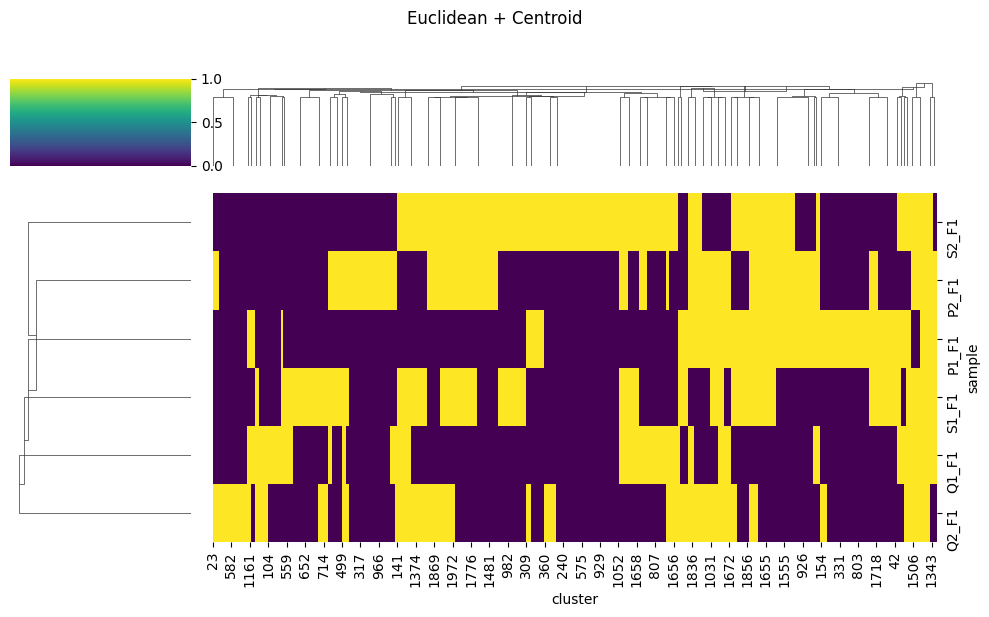

Метрика: cosine, Метод: average


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


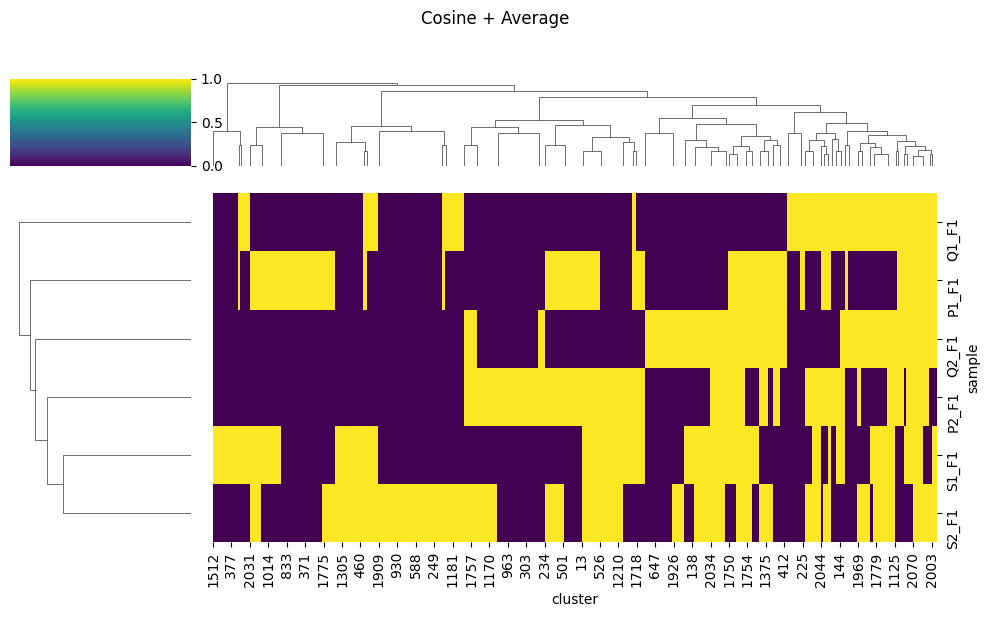

Метрика: cosine, Метод: single


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


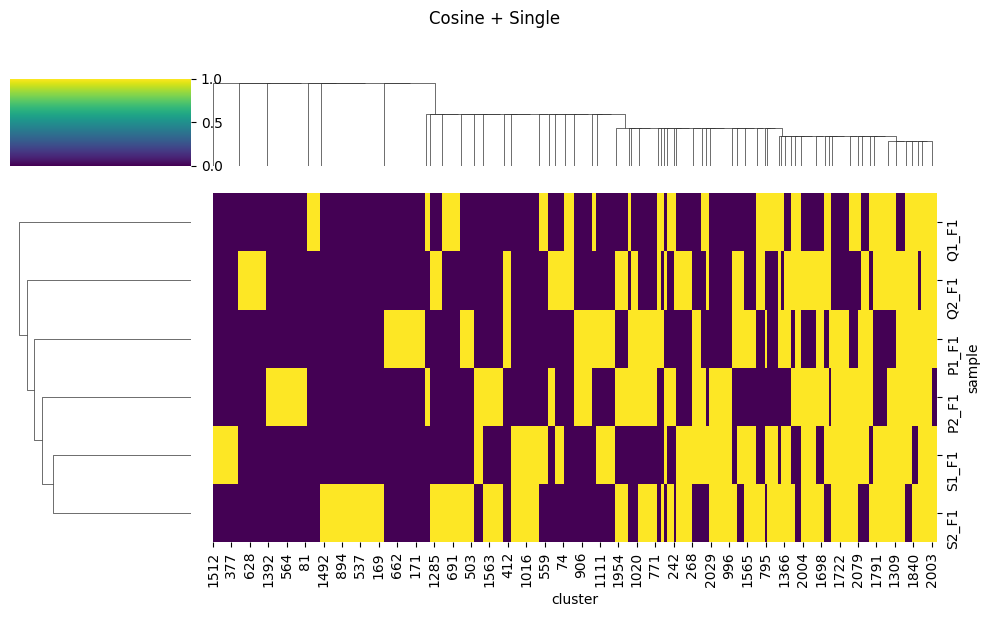

Метрика: cosine, Метод: complete


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


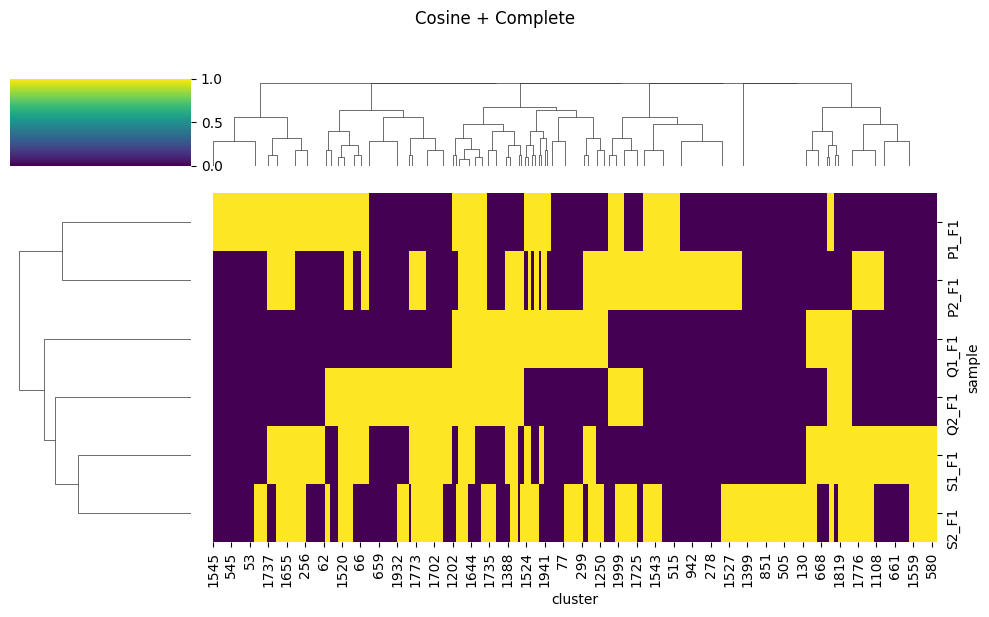

Метрика: cosine, Метод: weighted


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


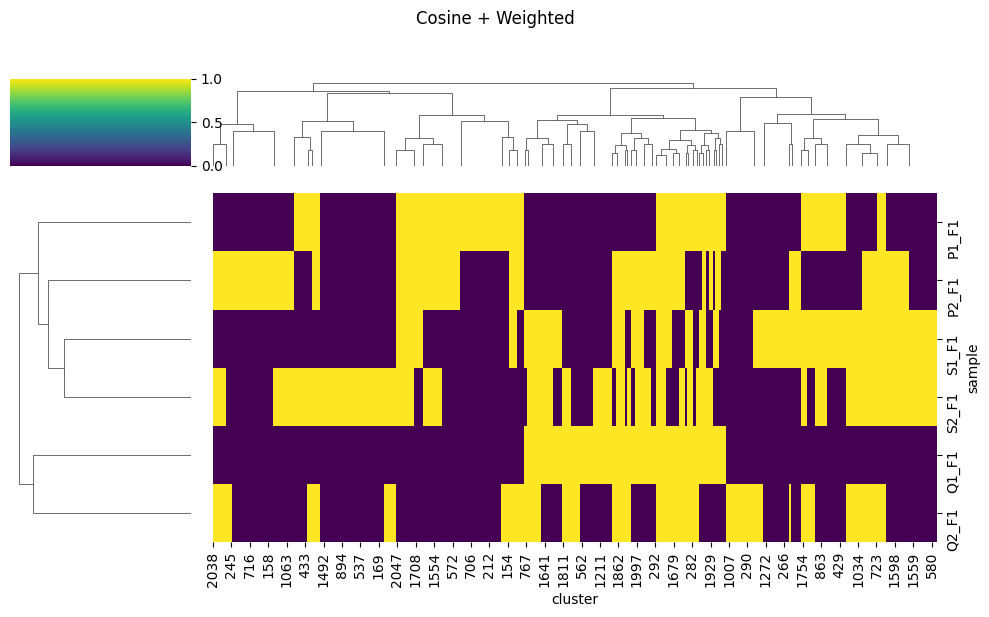

Метрика: cityblock, Метод: average


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


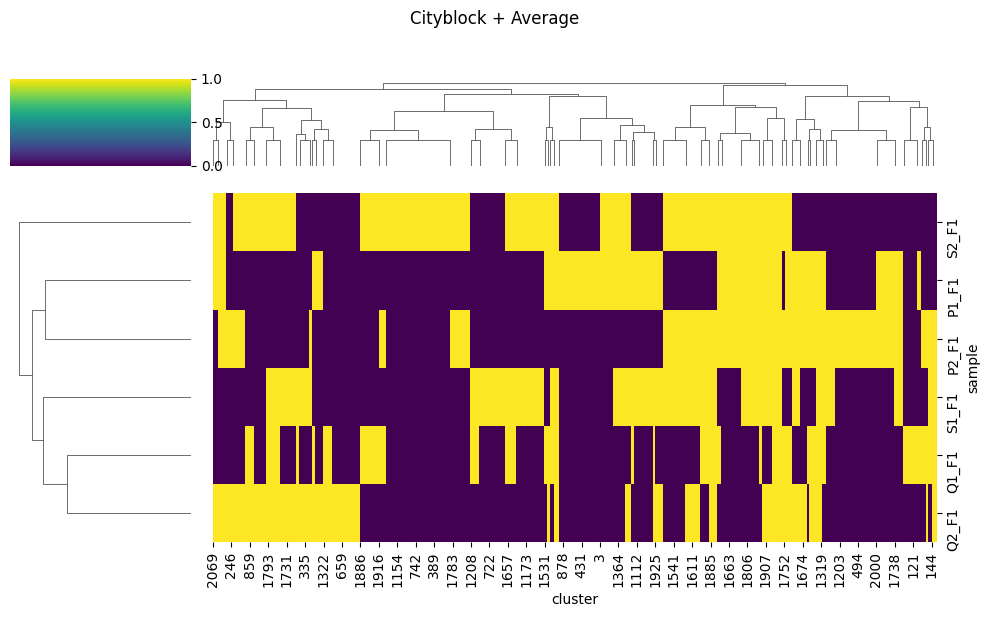

Метрика: cityblock, Метод: single


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


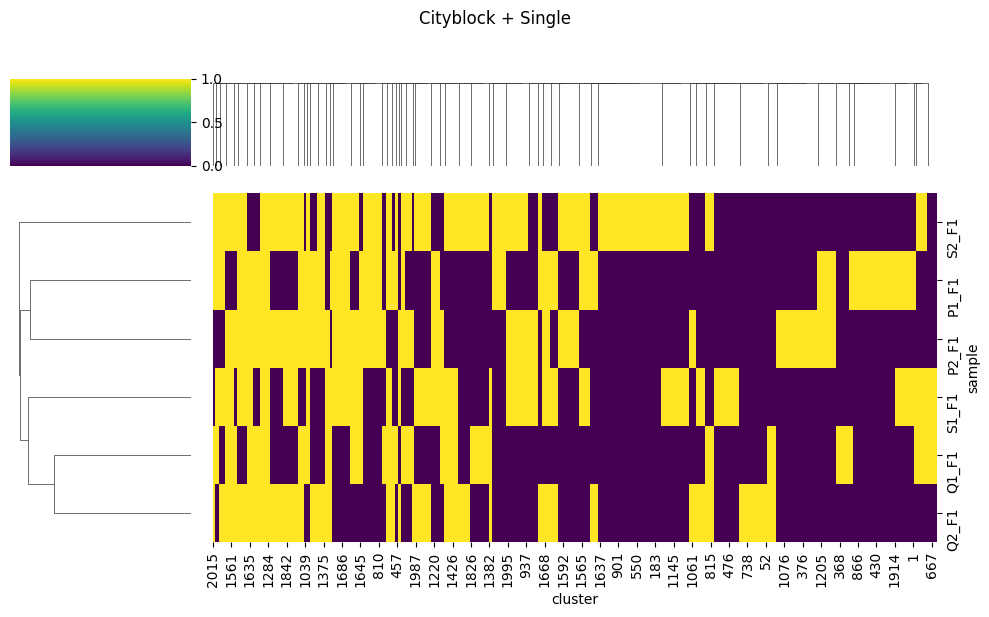

Метрика: cityblock, Метод: complete


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


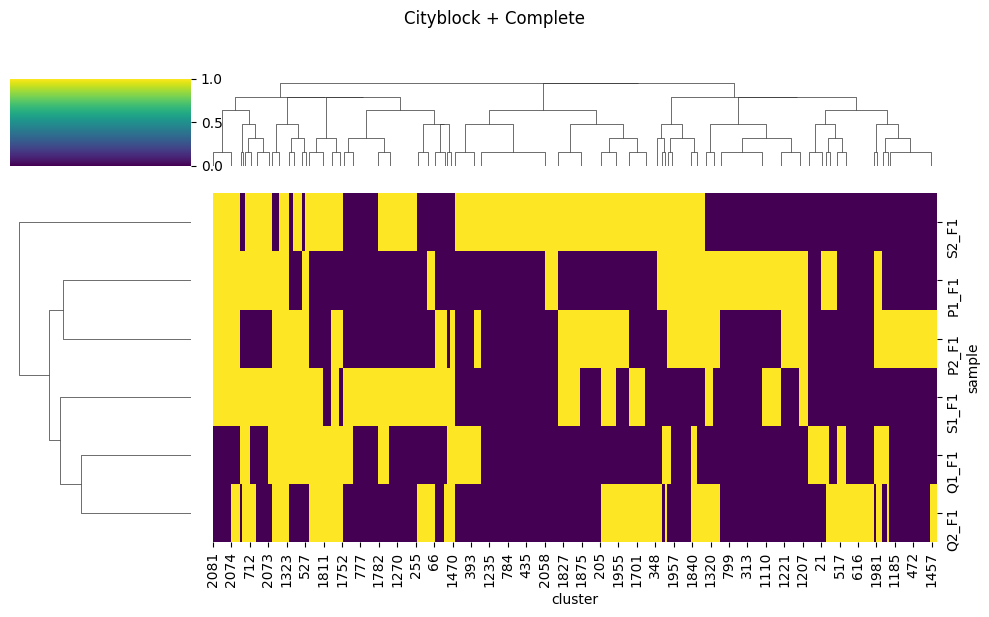

Метрика: cityblock, Метод: weighted


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


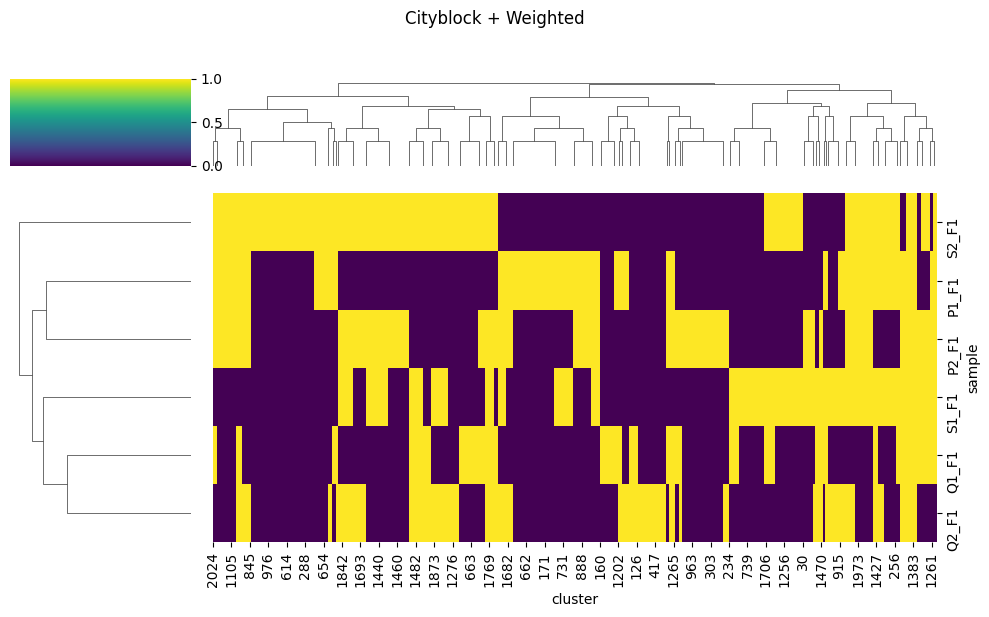

Метрика: correlation, Метод: average


/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/evlasova/.conda/envs/bio2025/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


ValueError: The condensed distance matrix must contain only finite values.

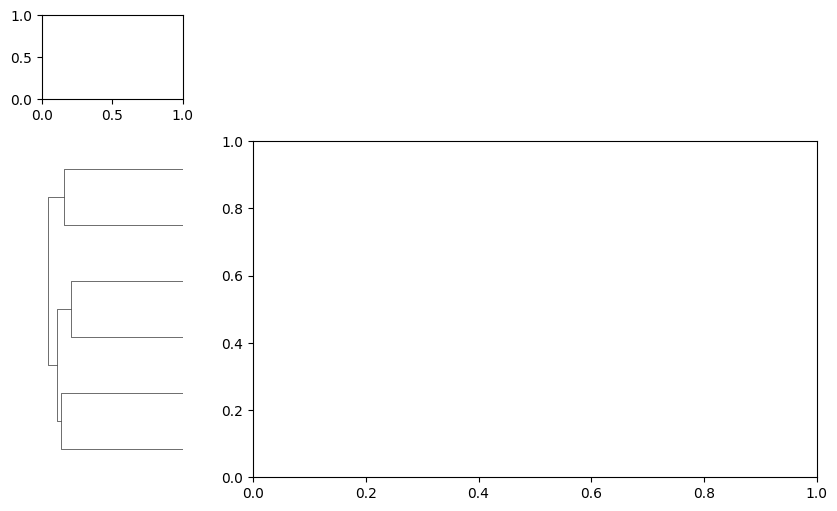

In [28]:
metrics = ['euclidean', 'cosine', 'cityblock', 'correlation', 'chebyshev']
methods = ['average', 'ward', 'single', 'complete', 'weighted', 'centroid']

for metric in metrics:
    for method in methods:
        # Ward требует евклидову метрику
        if method == 'ward' or method == 'centroid' and metric != 'euclidean':
            continue
        
        print(f"Метрика: {metric}, Метод: {method}")
        g = sns.clustermap(
            pivot_table_bool,
            metric=metric,
            method=method,
            cmap='viridis',
            figsize=(10, 6),
            # linewidths=0.1
        )
        g.fig.suptitle(f'{metric.capitalize()} + {method.capitalize()}', y=1.02)
        plt.tight_layout()
        plt.show()